In [1]:
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

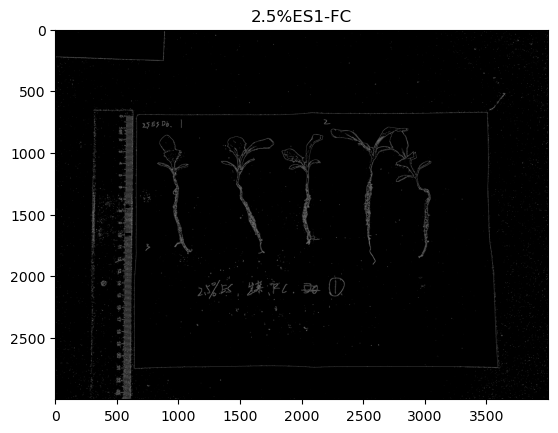

In [2]:
# binary
img = cv2.imread('GHPicture_2.5%ES/2.5%ES1-FC.jpg')
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
root = cv2.Canny(gray,80,90)
plt.subplot(111), plt.imshow(root,'gray'), plt.title('2.5%ES1-FC');

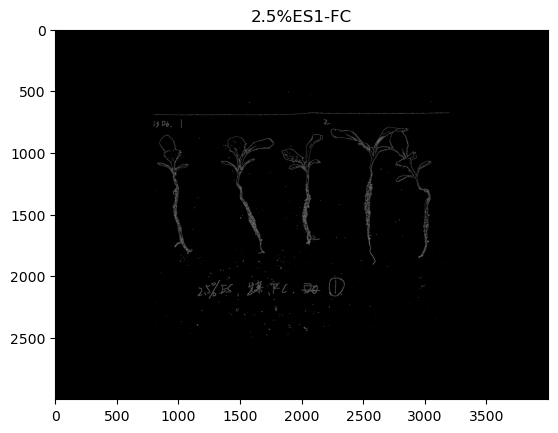

In [3]:
# 创建mask
mask = np.zeros(img.shape[:2], np.uint8)
h,w = img.shape[:2]
d_h = int(h/6)
d_w = int(w/5)
mask[d_h:h-d_h, d_w:w-d_w] = 255
masked_root = cv2.bitwise_and(root, root, mask=mask)#与操作
plt.subplot(111), plt.imshow(masked_root,'gray'), plt.title('2.5%ES1-FC');

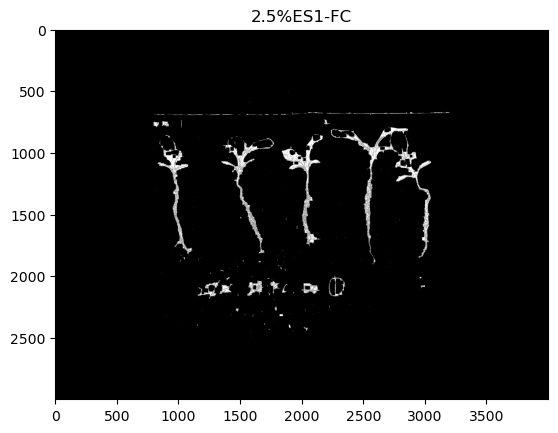

In [4]:
kernel = np.ones((3,3),np.uint8)
blackhat  = cv2.morphologyEx(masked_root,cv2.MORPH_BLACKHAT, kernel, iterations = 10) # remove detials
tophat = cv2.morphologyEx(blackhat, cv2.MORPH_TOPHAT, kernel,iterations = 20) # keep detials
plt.subplot(111), plt.imshow(tophat,'gray'), plt.title('2.5%ES1-FC');

In [5]:
contours, hierarchy = cv2.findContours(tophat, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)

1050 32341.5
2360 35914.5
3817 34611.0
5005 46182.0
6478 44615.0


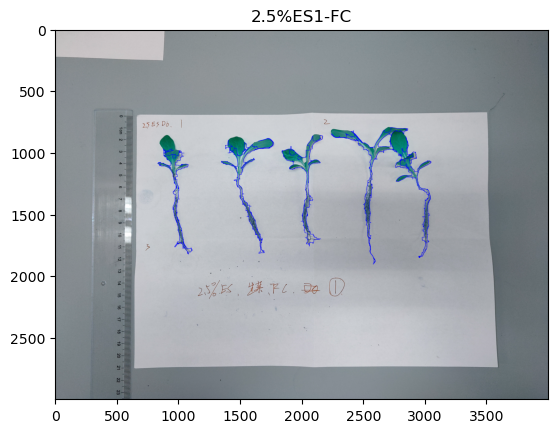

In [6]:
draw_img = img.copy()
root_contour_n = []
for i in range(len(contours)):
    cnt = contours[i]
    area = cv2.contourArea(cnt)
    arcL = cv2.arcLength(cnt,False)
    if area >30000:
        res = cv2.drawContours(draw_img, contours, i, (0, 0, 255), 2)
        print(i,cv2.contourArea(cnt))
        root_contour_n.append(i)
plt.subplot(111), plt.imshow(res), plt.title('2.5%ES1-FC');

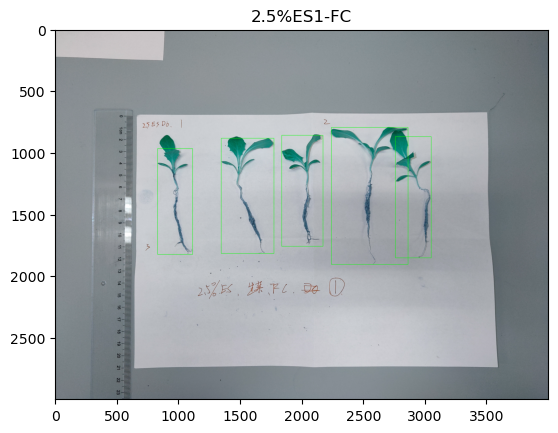

In [15]:
draw_img = img.copy()
plant = []
for i in root_contour_n:
    x,y,w,h = cv2.boundingRect(contours[i])
    res = cv2.rectangle(draw_img,(x,y),(x+w,y+h),(0,255,0),2)
    plant.append((x,y,w,h))
plt.subplot(111), plt.imshow(res), plt.title('2.5%ES1-FC');

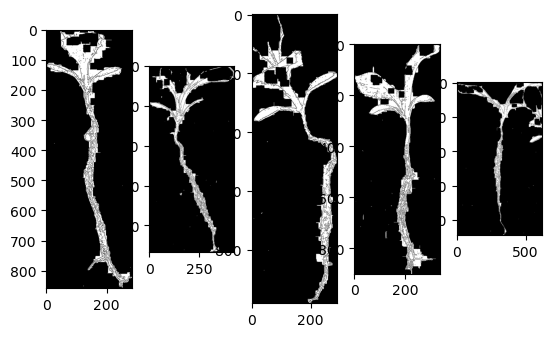

In [25]:
for i in range(len(plant)):
    x,y,w,h = plant[i]
    plant_img = tophat[y:y+h,x:x+w]
    plt.subplot(151+i), plt.imshow(plant_img,'gray')

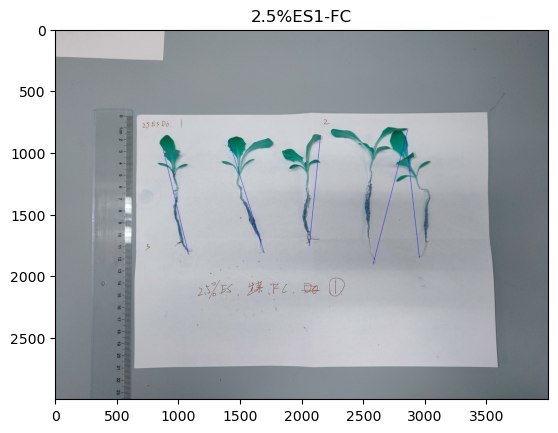

In [8]:
root_pix = [] # root_length
draw_img = img.copy()
for i in root_contour_n:
    cnt = contours[i]
    epsilon = 0.1*cv2.arcLength(cnt,True)
    approx = cv2.approxPolyDP(cnt,epsilon,True)
    res = cv2.drawContours(draw_img, [approx], -1, (0, 0, 255), 2)
    root_pix.append(cv2.arcLength(approx,False))
plt.subplot(111), plt.imshow(res), plt.title('2.5%ES1-FC');

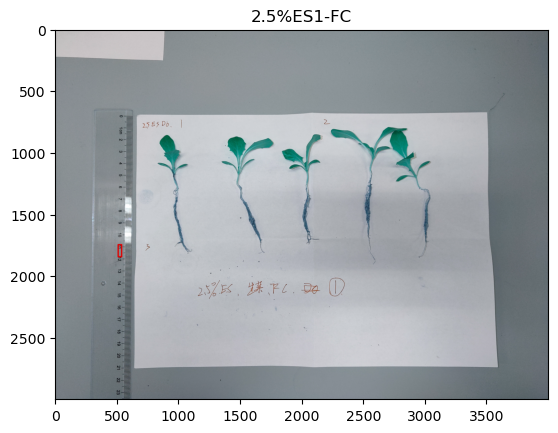

In [9]:
# match ruler
p_12 = []
for i in range(11,13):
    temple = cv2.imread(f'GHPicture_2.5%ES/ruler_{i}.png')
    temple_gray = cv2.cvtColor(temple,cv2.COLOR_BGR2GRAY)
    res = cv2.matchTemplate(gray,temple_gray,1)
    min_val,max_val,min_loc,max_loc = cv2.minMaxLoc(res)
    p_12.append(min_loc)
h,w = temple.shape[:2]
h = p_12[1][1]-p_12[0][1]

top_left = p_12[0]
bottom_right = (top_left[0]+w,top_left[1]+h)

img2 = img.copy()
cv2.rectangle(img2, top_left, bottom_right, 225, 10)
plt.subplot(111), plt.imshow(img2), plt.title('2.5%ES1-FC');

In [10]:
# h = 1cm
for i in root_pix:
    root_length = i/h
    print(root_length)

8.976541947345344
9.788310148278061
10.083078189772003
9.221379494180484
11.580126704001913
